# Single-Sensor Deployment Example

This notebook loads the stored configuration-conditional calibration artifact and applies it to one sensor stream. Unlike the old same-scene calibration flow, deployment only needs:

- the stored model,
- the deployed sensor identifier,
- the deployed campaign configuration,
- the deployed frequency grid,
- and that sensor's raw observations.

No shared-scene assumption is required at deployment time.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the current notebook cwd."""

    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "measurement_calibration").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not resolve the repository root from the notebook cwd")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from measurement_calibration import (
    DEFAULT_CAMPAIGNS_DATA_DIR,
    DEFAULT_CONFIGURATION_CONDITIONAL_MODELS_DIR,
    FrequencyBasisConfig,
    PersistentModelConfig,
    TwoLevelFitConfig,
    build_corpus_calibration_output_dir,
    calibrate_sensor_observations,
    evaluate_persistent_calibration,
    fit_and_save_calibration_corpus_model,
    load_two_level_calibration_artifact,
    power_linear_to_db,
    prepare_calibration_campaign,
    prepare_calibration_corpus,
)

CAMPAIGNS_ROOT = REPO_ROOT / DEFAULT_CAMPAIGNS_DATA_DIR
MODELS_ROOT = REPO_ROOT / DEFAULT_CONFIGURATION_CONDITIONAL_MODELS_DIR
TRAINING_CAMPAIGN_LABELS = ("MeasurementCalibration", "test-calibration")
MODEL_LABEL = "measurement_demo_corpus"
DEPLOYMENT_CAMPAIGN_LABEL = "MeasurementCalibration"
DEPLOYMENT_SENSOR_ID = "Node3"

BASIS_CONFIG = FrequencyBasisConfig(
    n_gain_basis=10,
    n_floor_basis=8,
    n_variance_basis=8,
    spline_degree=3,
)
MODEL_CONFIG = PersistentModelConfig(
    sensor_embedding_dim=4,
    configuration_latent_dim=4,
)
FIT_CONFIG = TwoLevelFitConfig(
    n_outer_iterations=8,
    n_gradient_steps=20,
    learning_rate=0.03,
    sigma_min=1.0e-8,
    adaptive_variance_floor_ratio=1.0e-4,
    select_best_outer_iterate=True,
    early_stopping_patience=5,
    divergence_tolerance_ratio=10.0,
    refresh_campaign_variance_from_residuals=True,
    variance_refresh_ridge=1.0e-6,
)

pd.set_option("display.max_columns", 32)
pd.set_option("display.max_rows", 32)

output_dir = build_corpus_calibration_output_dir(
    model_label=MODEL_LABEL,
    models_root=MODELS_ROOT,
)

## Load Or Build The Stored Model

The deployment notebook is self-contained: if the demo artifact does not exist yet, it prepares the training corpus and fits the same lightweight model configuration used in the training notebook.

In [2]:
if not (output_dir / "manifest.json").exists():
    preparation = prepare_calibration_corpus(
        campaign_labels=TRAINING_CAMPAIGN_LABELS,
        campaigns_root=CAMPAIGNS_ROOT,
    )
    fit_and_save_calibration_corpus_model(
        preparation=preparation,
        output_dir=output_dir,
        basis_config=BASIS_CONFIG,
        model_config=MODEL_CONFIG,
        fit_config=FIT_CONFIG,
    )

artifact = load_two_level_calibration_artifact(output_dir)
deployment_campaign = prepare_calibration_campaign(
    campaign_label=DEPLOYMENT_CAMPAIGN_LABEL,
    campaigns_root=CAMPAIGNS_ROOT,
)
available_sensor_ids = deployment_campaign.campaign.sensor_ids
sensor_id = (
    DEPLOYMENT_SENSOR_ID
    if DEPLOYMENT_SENSOR_ID in available_sensor_ids
    else deployment_campaign.reliable_sensor_id
)
sensor_index = available_sensor_ids.index(sensor_id)

deployment_inputs = pd.DataFrame(
    [
        {
            "model_dir": str(output_dir.relative_to(REPO_ROOT)),
            "deployment_campaign": deployment_campaign.campaign_label,
            "deployment_sensor_id": sensor_id,
            "reliable_sensor_id": deployment_campaign.reliable_sensor_id,
            "n_records": deployment_campaign.campaign.n_acquisitions,
            "n_frequencies": deployment_campaign.campaign.n_frequencies,
            "central_freq_MHz": deployment_campaign.campaign.configuration.central_frequency_hz / 1.0e6,
            "span_MHz": deployment_campaign.campaign.configuration.span_hz / 1.0e6,
            "rbw_kHz": deployment_campaign.campaign.configuration.resolution_bandwidth_hz / 1.0e3,
        }
    ]
)
display(deployment_inputs)

,model_dir,deployment_campaign,deployment_sensor_id,reliable_sensor_id,n_records,n_frequencies,central_freq_MHz,span_MHz,rbw_kHz
0,models/configuration_conditional_calibration/m...,MeasurementCalibration,Node3,Node2,179,4096,98.0,20.0,10.0


## Evaluate Persistent Laws And Calibrate One Sensor Stream

The next cell uses only the selected sensor's observations. The trust diagnostics expose whether the request lies inside the training support in frequency and configuration space.

In [3]:
raw_power = deployment_campaign.campaign.observations_power[sensor_index]
curves = evaluate_persistent_calibration(
    result=artifact.result,
    sensor_id=sensor_id,
    configuration=deployment_campaign.campaign.configuration,
    frequency_hz=deployment_campaign.campaign.frequency_hz,
)
deployment = calibrate_sensor_observations(
    result=artifact.result,
    sensor_id=sensor_id,
    configuration=deployment_campaign.campaign.configuration,
    frequency_hz=deployment_campaign.campaign.frequency_hz,
    observations_power=raw_power,
)

trust_frame = pd.DataFrame(
    [
        {
            "frequency_support_hz": curves.trust_diagnostics.frequency_support_hz,
            "requested_frequency_hz": curves.trust_diagnostics.requested_frequency_hz,
            "frequency_extrapolation_detected": curves.trust_diagnostics.frequency_extrapolation_detected,
            "configuration_out_of_distribution": curves.trust_diagnostics.configuration_out_of_distribution,
            "out_of_range_feature_names": ", ".join(curves.trust_diagnostics.out_of_range_feature_names) or "-",
            "max_abs_standardized_feature": curves.trust_diagnostics.max_abs_standardized_feature,
        }
    ]
)
display(trust_frame)

summary_frame = pd.DataFrame(
    [
        {
            "mean_raw_power_db": float(power_linear_to_db(raw_power).mean()),
            "mean_corrected_power_db": float(power_linear_to_db(deployment.calibrated_power).mean()),
            "mean_gain_db": float(power_linear_to_db(curves.gain_power).mean()),
            "mean_floor_db": float(power_linear_to_db(curves.additive_noise_power).mean()),
            "mean_propagated_variance_db": float(power_linear_to_db(deployment.propagated_variance_power2).mean()),
        }
    ]
)
display(summary_frame)

,frequency_support_hz,requested_frequency_hz,frequency_extrapolation_detected,configuration_out_of_distribution,out_of_range_feature_names,max_abs_standardized_feature
0,"(88000000.0, 108000000.0)","(88000000.0, 108000000.0)",False,False,-,0.0


,mean_raw_power_db,mean_corrected_power_db,mean_gain_db,mean_floor_db,mean_propagated_variance_db
0,-20.23832,-17.899658,-2.841576,-31.566969,-10.836877


## Deployment Plots

The first row compares one deployed PSD realization before and after calibration. The second row shows the mean deployed spectrum and the persistent calibration laws used for this sensor/configuration pair.

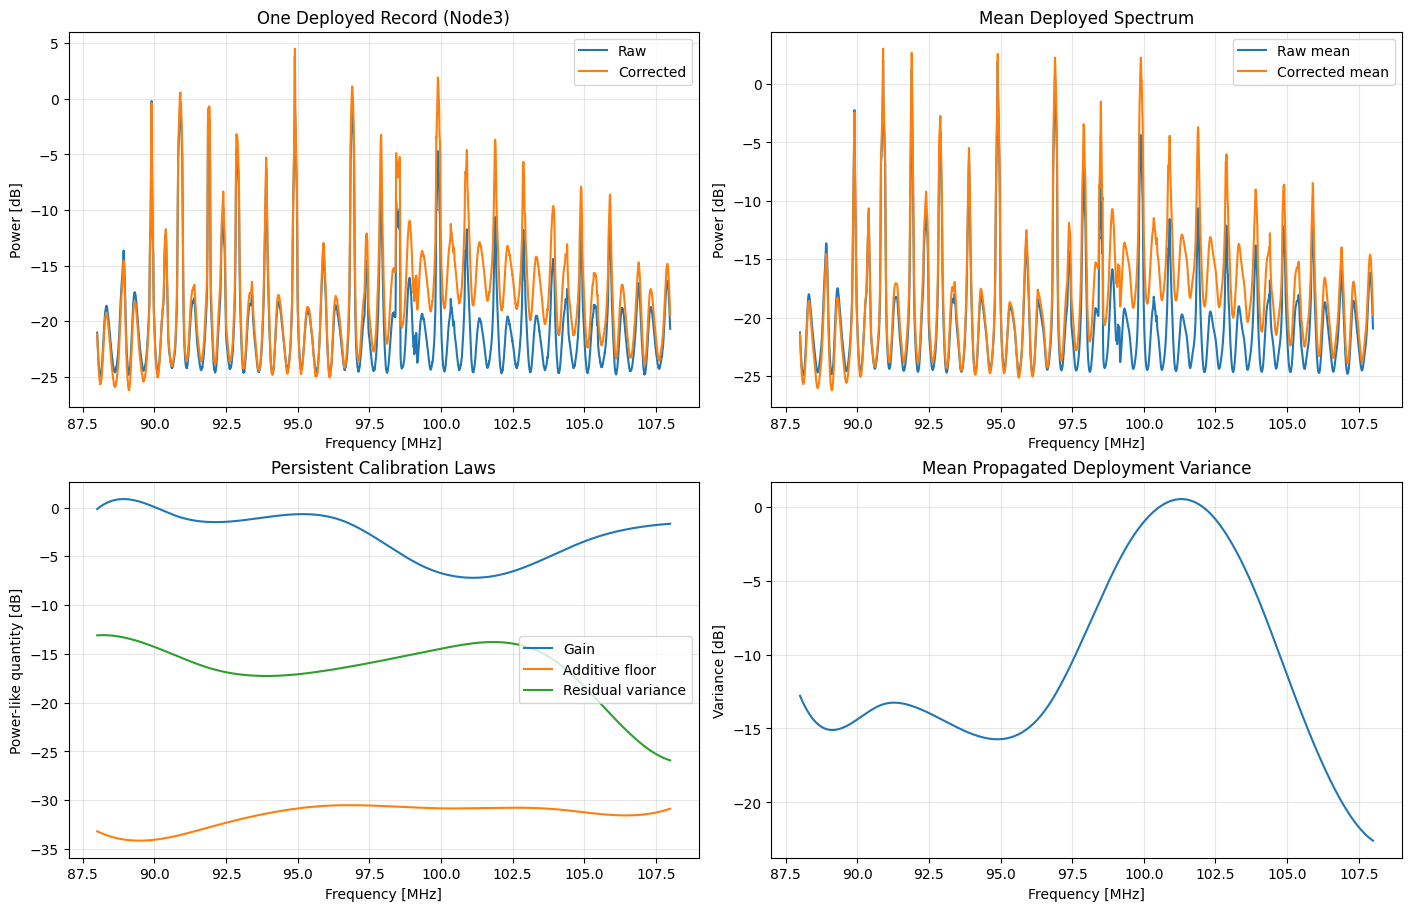

In [4]:
record_index = 0
frequency_mhz = deployment_campaign.campaign.frequency_hz / 1.0e6
raw_record_db = power_linear_to_db(raw_power[record_index])
corrected_record_db = power_linear_to_db(deployment.calibrated_power[record_index])
raw_mean_db = power_linear_to_db(np.mean(raw_power, axis=0))
corrected_mean_db = power_linear_to_db(np.mean(deployment.calibrated_power, axis=0))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

axes[0, 0].plot(frequency_mhz, raw_record_db, label="Raw")
axes[0, 0].plot(frequency_mhz, corrected_record_db, label="Corrected")
axes[0, 0].set_title(f"One Deployed Record ({sensor_id})")
axes[0, 0].set_xlabel("Frequency [MHz]")
axes[0, 0].set_ylabel("Power [dB]")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(loc="best")

axes[0, 1].plot(frequency_mhz, raw_mean_db, label="Raw mean")
axes[0, 1].plot(frequency_mhz, corrected_mean_db, label="Corrected mean")
axes[0, 1].set_title("Mean Deployed Spectrum")
axes[0, 1].set_xlabel("Frequency [MHz]")
axes[0, 1].set_ylabel("Power [dB]")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(loc="best")

axes[1, 0].plot(frequency_mhz, power_linear_to_db(curves.gain_power), label="Gain")
axes[1, 0].plot(
    frequency_mhz,
    power_linear_to_db(curves.additive_noise_power),
    label="Additive floor",
)
axes[1, 0].plot(
    frequency_mhz,
    power_linear_to_db(curves.residual_variance_power2),
    label="Residual variance",
)
axes[1, 0].set_title("Persistent Calibration Laws")
axes[1, 0].set_xlabel("Frequency [MHz]")
axes[1, 0].set_ylabel("Power-like quantity [dB]")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(loc="best")

axes[1, 1].plot(
    frequency_mhz,
    power_linear_to_db(np.mean(deployment.propagated_variance_power2, axis=0)),
)
axes[1, 1].set_title("Mean Propagated Deployment Variance")
axes[1, 1].set_xlabel("Frequency [MHz]")
axes[1, 1].set_ylabel("Variance [dB]")
axes[1, 1].grid(alpha=0.3)

plt.show()